In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import os

In [20]:
# --- 1) Loading Merged dataset ---
DATA_PATH = "../Final_Dataset/final_merged_sleep_lifestyle.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Age,Weight (kg)_mean,Height (m)_mean,Calories_Burned_mean,Water_Intake (liters)_mean,Workout_Frequency (days/week)_mean,BMI_mean,Physical exercise_mean,Carbs_mean,Proteins_mean,...,diet_type_Vegetarian_pct,cooking_method_Baked_pct,cooking_method_Boiled_pct,cooking_method_Raw_pct,cooking_method_Steamed_pct,cooking_method_Fried_pct,cooking_method_Roasted_pct,cooking_method_Grilled_pct,Sleep Disorder_Sleep Apnea_pct,Sleep Disorder_Insomnia_pct
0,18,74.07,1.70,1318.12,2.52,3.13,25.71,0.05,234.99,93.99,...,16.16,12.93,14.07,14.45,12.93,14.83,14.26,16.54,0.445,0.4
1,19,72.99,1.74,1271.32,2.55,3.27,24.12,0.24,225.79,90.29,...,16.67,13.29,13.49,12.10,16.27,14.29,15.48,15.08,0.445,0.4
2,20,85.38,1.75,1222.69,2.64,3.25,27.49,0.43,252.43,100.96,...,15.20,14.99,15.85,14.35,12.21,13.06,16.27,13.28,0.445,0.4
3,21,78.07,1.72,1362.45,2.73,3.27,26.40,0.56,262.86,105.17,...,17.80,17.07,12.44,14.63,14.63,13.90,12.44,14.88,0.445,0.4
4,22,76.83,1.72,1313.52,2.45,3.50,25.82,0.35,247.21,98.92,...,18.01,14.89,13.42,15.99,15.44,13.79,13.24,13.24,0.445,0.4


In [9]:
print("Dataset loaded successfully!")
print(df.shape)
print(df.head())

Dataset loaded successfully!
(43, 43)
   Age  Weight (kg)_mean  Height (m)_mean  Calories_Burned_mean  \
0   18             74.07             1.70               1318.12   
1   19             72.99             1.74               1271.32   
2   20             85.38             1.75               1222.69   
3   21             78.07             1.72               1362.45   
4   22             76.83             1.72               1313.52   

   Water_Intake (liters)_mean  Workout_Frequency (days/week)_mean  BMI_mean  \
0                        2.52                                3.13     25.71   
1                        2.55                                3.27     24.12   
2                        2.64                                3.25     27.49   
3                        2.73                                3.27     26.40   
4                        2.45                                3.50     25.82   

   Physical exercise_mean  Carbs_mean  Proteins_mean  ...  \
0                    0.

In [10]:
# Target columns
stress_col = "Stress Level_mean"
sleep_quality_col = "Quality of Sleep_mean"
calories_col = "Calories_mean"

#### ==============================================================
#### A2 — Quality of Sleep vs Stress (Pearson correlation)
#### ==============================================================

**Null Hypothesis (H₀):**  
There is **no linear correlation** between Sleep Quality and Stress.

**Alternative Hypothesis (H₁):**  
There **is a linear correlation** between Sleep Quality and Stress.

**Decision Rule:**  
- If **p < 0.05** → Reject H₀  
- If **p ≥ 0.05** → Fail to reject H₀

In [11]:

print("\n=== A2: Quality of Sleep vs Stress (Pearson correlation) ===")

q_data = df[[sleep_quality_col, stress_col]].dropna()

r_qs, p_qs = stats.pearsonr(q_data[sleep_quality_col], q_data[stress_col])

print(f"n = {len(q_data)}")
print(f"Pearson r = {r_qs:.6f}")
print(f"p-value = {p_qs:.6e}")


=== A2: Quality of Sleep vs Stress (Pearson correlation) ===
n = 43
Pearson r = -0.912593
p-value = 1.605303e-17


##### The strong negative correlation clearly shows that when sleep quality improves, stress levels decrease a lot.
##### The p-value is extremely small, which means this result is highly significant and not random.
##### Overall, this test helped to understand that sleep quality is one of the strongest lifestyle factors affecting stress in our dataset — better sleep directly links to lower stress. 

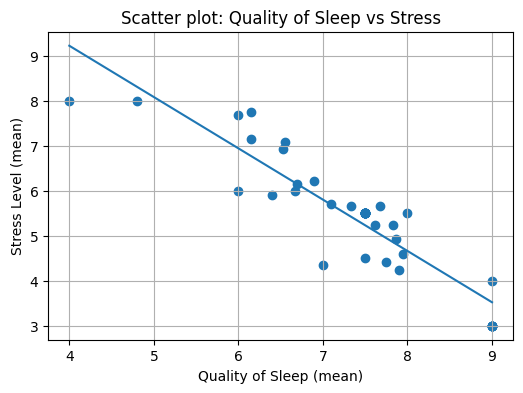

In [12]:
#### --------------------------------------------------------------
#### Scatter + Regression (Quality vs Stress)
#### --------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(q_data[sleep_quality_col], q_data[stress_col])

# Regression line
m, b = np.polyfit(q_data[sleep_quality_col], q_data[stress_col], 1)
xs = np.linspace(q_data[sleep_quality_col].min(), q_data[sleep_quality_col].max(), 100)
plt.plot(xs, m*xs + b)

plt.xlabel("Quality of Sleep (mean)")
plt.ylabel("Stress Level (mean)")
plt.title("Scatter plot: Quality of Sleep vs Stress")
plt.grid(True)
plt.show()

#### ==============================================================
#### A13 — Diet % vs Stress (Pearson correlations for each diet type)
#### ==============================================================

**Null Hypothesis (H₀):**  
Diet percentage has **no linear correlation** with Stress.

**Alternative Hypothesis (H₁):**  
Diet percentage **is linearly correlated** with Stress.

**Decision Rule:**  
- If **p < 0.05** → Reject H₀  
- If **p ≥ 0.05** → Fail to reject H₀

In [13]:

print("\n=== A13: Diet % vs Stress (Pearson correlations) ===")

diet_cols = [c for c in df.columns if c.startswith("diet_type_") and c.endswith("_pct")]

diet_corr_list = []
for col in diet_cols:
    data = df[[col, stress_col]].dropna()
    r, p = stats.pearsonr(data[col], data[stress_col])
    diet_corr_list.append([col, r, p, len(data)])

diet_corr_df = pd.DataFrame(diet_corr_list, columns=["diet_col", "r", "p", "n"])
print(diet_corr_df)



=== A13: Diet % vs Stress (Pearson correlations) ===
                   diet_col         r         p   n
0    diet_type_Low-Carb_pct -0.242774  0.116733  43
1       diet_type_Vegan_pct -0.099683  0.524781  43
2        diet_type_Keto_pct  0.101546  0.517024  43
3    diet_type_Balanced_pct  0.052563  0.737812  43
4       diet_type_Paleo_pct  0.113866  0.467204  43
5  diet_type_Vegetarian_pct  0.117554  0.452806  43


#### These results clearly show that diet type percentages do not have any significant relationship with stress in our dataset. The correlations are weak and the p-values indicate no statistical significance. 
#### Overall, this test helped to understand that diet has almost no influence on stress, especially when compared to stronger predictors like sleep quality.

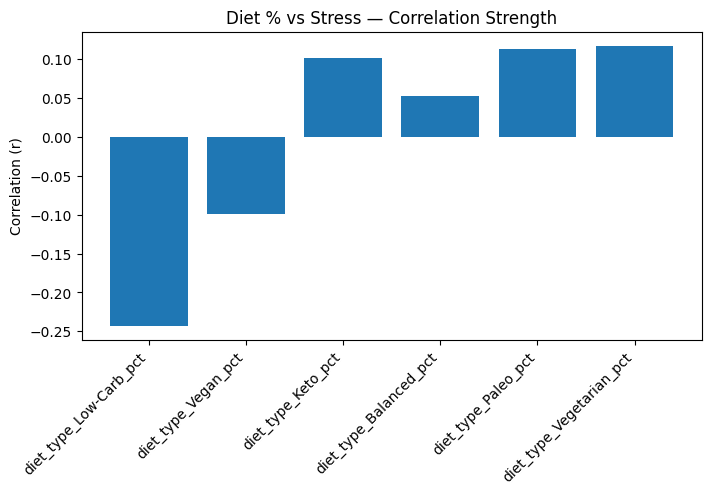

In [14]:
#### --------------------------------------------------------------
#### Diet Correlation Bar Chart
#### --------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.bar(diet_corr_df["diet_col"], diet_corr_df["r"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Correlation (r)")
plt.title("Diet % vs Stress — Correlation Strength")
plt.show()

#### ==============================================================
#### B1 — High Calories vs Low Calories → Stress (t-test)
#### ==============================================================

**Null Hypothesis (H₀):**  
Mean Stress is **the same** for High-Calorie and Low-Calorie groups.

**Alternative Hypothesis (H₁):**  
Mean Stress **differs** between the two groups.

**Decision Rule:**  
- If **p < 0.05** → Reject H₀  
- If **p ≥ 0.05** → Fail to reject H₀

In [15]:

print("\n=== B1: High Calories vs Low Calories → Stress (Independent t-test) ===")

cal_data = df[[calories_col, stress_col]].dropna().copy()

median_cal = cal_data[calories_col].median()
cal_data["cal_group"] = np.where(cal_data[calories_col] >= median_cal, "High", "Low")

high = cal_data[cal_data["cal_group"] == "High"][stress_col]
low  = cal_data[cal_data["cal_group"] == "Low"][stress_col]

t_stat, p_val = stats.ttest_ind(high, low, equal_var=False)

print(f"Median Calories = {median_cal:.2f}")
print(f"High group mean stress = {high.mean():.4f}")
print(f"Low group mean stress  = {low.mean():.4f}")
print(f"t = {t_stat:.6f}, p = {p_val:.6e}")


=== B1: High Calories vs Low Calories → Stress (Independent t-test) ===
Median Calories = 2012.33
High group mean stress = 5.2868
Low group mean stress  = 5.4614
t = -0.421734, p = 6.755077e-01


#### The average stress levels for both High-Calorie and Low-Calorie groups are almost the same, and the p-value is much greater than 0.05 so we failed to reject the Ho.
#### This clearly shows that calorie intake does not have a significant effect on stress in our dataset.
#### The t-test confirms that there is no statistically meaningful difference in stress between people who consume higher calories and those who consume lower calories.

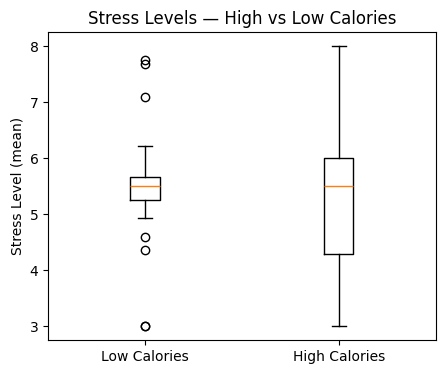

In [21]:
#### --------------------------------------------------------------
#### Boxplot — High vs Low Calories
#### --------------------------------------------------------------
plt.figure(figsize=(5,4))
plt.boxplot([low.values, high.values], tick_labels=["Low Calories", "High Calories"])
plt.ylabel("Stress Level (mean)")
plt.title("Stress Levels — High vs Low Calories")
plt.show()


#### ==============================================================
#### ANOVA — Sleep Quality Groups → Stress
#### ==============================================================

**Null Hypothesis (H₀):**  
All Sleep Quality groups have **equal mean Stress scores**.

**Alternative Hypothesis (H₁):**  
At least **one** group has a different mean Stress score.

**Decision Rule:**  
- If **p < 0.05** → Reject H₀  
- If **p ≥ 0.05** → Fail to reject H₀

In [17]:

print("\n=== ANOVA: Sleep Quality Groups → Stress ===")

q1, q2 = df[sleep_quality_col].quantile([0.33, 0.66])
df["sleep_quality_group"] = pd.cut(df[sleep_quality_col], bins=[-999999, q1, q2, 999999],
                                   labels=["Low", "Medium", "High"])

groups = [df[df["sleep_quality_group"] == g][stress_col].dropna().values
          for g in ["Low", "Medium", "High"]]

F_val, p_val = stats.f_oneway(*groups)

print(f"Group sizes: {[len(g) for g in groups]}")
print(f"F = {F_val:.6f}, p = {p_val:.6e}")


=== ANOVA: Sleep Quality Groups → Stress ===
Group sizes: [14, 14, 15]
F = 29.806764, p = 1.188046e-08


#### The ANOVA result shows a very large F-value and an extremely small p-value. This means the three sleep-quality groups (Low, Medium, High) have significantly different stress levels.
#### In simple terms, stress changes a lot depending on how good a person’s sleep quality is. 
#### This test made it clear that sleep quality has a major impact on stress, and the difference across groups is statistically very strong.

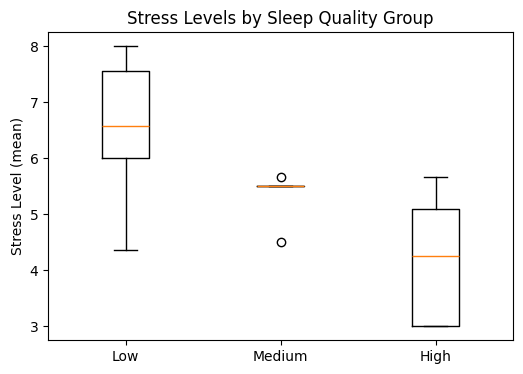

In [22]:
#### --------------------------------------------------------------
#### Boxplot — Sleep Quality Groups
#### --------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.boxplot(groups, tick_labels=["Low", "Medium", "High"])
plt.ylabel("Stress Level (mean)")
plt.title("Stress Levels by Sleep Quality Group")
plt.show()